# Supplementary Figure SR5 — unique diseases against unique therapeutic areas per cluster

Reviewer 1, minor comment 9: the data behind the Spearman correlation quoted in Results 4
should be shown as a supplementary figure. One point per distinct integer coordinate over the
20,041 colocalisation clusters of `variant_clusters`; `uniqueDiseases` is the variant pleiotropy
score (vPS) and `uniqueTherapeuticAreas` is the same cluster's therapeutic-area count under the
Supplementary Table 9 hierarchy order.

Both counts are small integers over 20,041 clusters, so a plain scatter is a solid block at the
origin. Nothing is subsampled and no jitter is applied: the clusters collapse onto a few hundred
integer coordinates and each is drawn once with **marker area proportional to $\sqrt{n}$**
(radius $\propto n^{1/4}$). Area $\propto n$ was rejected — the modal coordinate holds two thirds
of all clusters and would swamp the panel. A size key gives the count-to-area mapping.

> **Numbering.** This is the figure printed as **Supplementary Figure 5**. The manuscript's
> asset filename and internal label for it are `figures/figure_sr6.pdf` and `fig:sr6` —
> the filenames and label names of SR 5 and SR 6 are swapped relative to the numbers they render
> as, because the two figures appear in the source in the opposite order. Notebooks and outputs
> here are named after the **printed** number. Do not copy this PDF over the manuscript's
> `figure_sr6.pdf` without checking `FIGURE_MAPPING.md` first.

Writes `figure_sr5.pdf`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

from manuscript_methods import paper

BLUE = "#1f77b4"
SIZE_SCALE = 6.0  # marker area in pt^2 = SIZE_SCALE * sqrt(n_clusters)
FIGURE_DIR = paper.ROOT / "chapters" / "05-figures-supplementary" / "supplementary"

clusters = pd.read_parquet(paper.derived("variant_clusters"))
diseases, areas = clusters["uniqueDiseases"], clusters["uniqueTherapeuticAreas"]
n = len(clusters)
rho, pvalue = stats.spearmanr(diseases, areas)
print(f"clusters {n:,} | Spearman rho = {rho:.6f}  P = {pvalue:.3e}")

clusters 20,041 | Spearman rho = 0.837808  P = 0.000e+00


## The coordinates plotted

In [2]:
counts = (
    clusters.groupby(["uniqueDiseases", "uniqueTherapeuticAreas"])
    .size()
    .rename("n_clusters")
    .reset_index()
    .rename(columns={"uniqueDiseases": "diseases", "uniqueTherapeuticAreas": "tas"})
)
assert counts["n_clusters"].sum() == n
modal = int(counts["n_clusters"].max())
modal_at = counts.loc[counts["n_clusters"].idxmax(), ["diseases", "tas"]].tolist()

print("distinct coordinates:", len(counts))
print(f"modal coordinate: {modal:,} clusters at {tuple(modal_at)} ({modal / n:.1%})")
print("diseases 1-%d, mean %.4f | areas 1-%d, mean %.4f" % (diseases.max(), diseases.mean(), areas.max(), areas.mean()))
counts.sort_values("n_clusters", ascending=False).head(10)

distinct coordinates: 226
modal coordinate: 13,424 clusters at (1, 1) (67.0%)
diseases 1-120, mean 2.1415 | areas 1-19, mean 1.4477


,diseases,tas,n_clusters
0,1,1,13424
2,2,2,1657
1,2,1,1414
4,3,2,687
5,3,3,344
7,4,2,274
3,3,1,265
8,4,3,200
11,5,2,119
12,5,3,116


## The figure

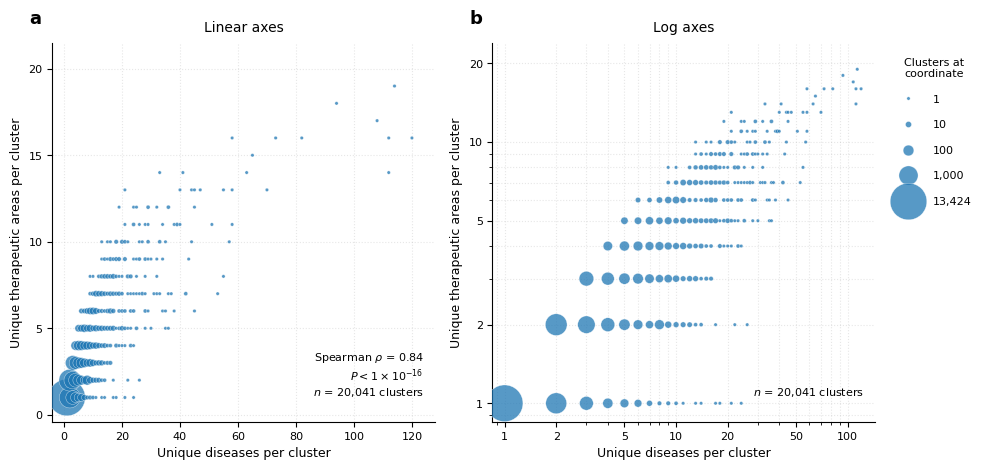

saved figure_sr5.pdf


In [3]:
def marker_area(n_clusters):
    return SIZE_SCALE * np.sqrt(n_clusters)


def draw(ax, sub, logscale):
    ax.scatter(
        sub["diseases"],
        sub["tas"],
        s=marker_area(sub["n_clusters"]),
        color=BLUE,
        alpha=0.75,
        linewidths=0.3,
        edgecolors="white",
        zorder=10,
    )
    ax.set_xlabel("Unique diseases per cluster", fontsize=9)
    ax.set_ylabel("Unique therapeutic areas per cluster", fontsize=9)
    ax.grid(True, which="both", ls=":", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        for axis, ticks in ((ax.xaxis, [1, 2, 5, 10, 20, 50, 100]), (ax.yaxis, [1, 2, 5, 10, 20])):
            axis.set_major_formatter(plt.ScalarFormatter())
            axis.set_minor_formatter(plt.NullFormatter())
            axis.set_ticks(ticks)
        ax.set_xlim(0.85, 145)
        ax.set_ylim(0.85, 24)
    else:
        ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
        ax.set_yticks([0, 5, 10, 15, 20])
        ax.set_xlim(-4, 128)
        ax.set_ylim(-0.4, 21.5)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

draw(axes[0], counts, logscale=False)
axes[0].set_title("Linear axes", fontsize=10, pad=8)
axes[0].text(
    0.97,
    0.06,
    f"Spearman $\\rho$ = {rho:.2f}\n$P < 1 \\times 10^{{-16}}$\n$n$ = {n:,} clusters",
    transform=axes[0].transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
)

draw(axes[1], counts, logscale=True)
axes[1].set_title("Log axes", fontsize=10, pad=8)
axes[1].text(0.97, 0.06, f"$n$ = {n:,} clusters", transform=axes[1].transAxes, fontsize=8, ha="right", va="bottom")

for ax, tag in zip(axes, ["a", "b"]):
    ax.text(-0.06, 1.04, tag, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom")

handles = [
    Line2D(
        [],
        [],
        marker="o",
        ls="none",
        color=BLUE,
        alpha=0.75,
        markeredgecolor="white",
        markeredgewidth=0.3,
        markersize=np.sqrt(marker_area(k)),
        label=f"{k:,}",
    )
    for k in [1, 10, 100, 1000, modal]
]
axes[1].legend(
    handles=handles,
    title="Clusters at\ncoordinate",
    frameon=False,
    fontsize=8,
    title_fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    labelspacing=1.4,
    borderpad=0.8,
    handletextpad=1.2,
)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "figure_sr5.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr5.pdf")

Both counts have a minimum of 1, so both panels plot all 20,041 clusters and the log panel drops
nothing.

## Exact numbers plotted

In [4]:
summary = pd.DataFrame(
    [
        ("clusters plotted (both panels)", n),
        ("distinct coordinates", len(counts)),
        ("modal coordinate", f"{tuple(modal_at)}"),
        ("clusters at the modal coordinate", modal),
        ("unique diseases: min / max", f"{int(diseases.min())} / {int(diseases.max())}"),
        ("unique diseases: mean", round(float(diseases.mean()), 4)),
        ("unique therapeutic areas: min / max", f"{int(areas.min())} / {int(areas.max())}"),
        ("unique therapeutic areas: mean", round(float(areas.mean()), 4)),
        ("clusters with >1 disease", int((diseases > 1).sum())),
        ("clusters with >1 therapeutic area", int((areas > 1).sum())),
        ("Spearman rho", round(float(rho), 6)),
        ("Spearman P", f"{pvalue:.3e}"),
    ],
    columns=["quantity", "value"],
)
print(summary.to_string(index=False))

                           quantity     value
     clusters plotted (both panels)     20041
               distinct coordinates       226
                   modal coordinate    (1, 1)
   clusters at the modal coordinate     13424
         unique diseases: min / max   1 / 120
              unique diseases: mean    2.1415
unique therapeutic areas: min / max    1 / 19
     unique therapeutic areas: mean    1.4477
           clusters with >1 disease      6617
  clusters with >1 therapeutic area      4766
                       Spearman rho  0.837808
                         Spearman P 0.000e+00


In [5]:
top = counts.sort_values("n_clusters", ascending=False).head(15).reset_index(drop=True)
top["pct_of_clusters"] = (top["n_clusters"] / n * 100).round(2)
print("15 most populated coordinates:")
print(top.to_string(index=False))
print(f"\ntop 10 cover {top.head(10)['n_clusters'].sum():,} clusters ({top.head(10)['n_clusters'].sum() / n:.1%})")

15 most populated coordinates:
 diseases  tas  n_clusters  pct_of_clusters
        1    1       13424            66.98
        2    2        1657             8.27
        2    1        1414             7.06
        3    2         687             3.43
        3    3         344             1.72
        4    2         274             1.37
        3    1         265             1.32
        4    3         200             1.00
        5    2         119             0.59
        5    3         116             0.58
        6    3          93             0.46
        4    1          79             0.39
        5    4          72             0.36
        8    2          68             0.34
        6    4          65             0.32

top 10 cover 18,500 clusters (92.3%)
